In [1]:
from typing import Tuple

import numpy as np


import time

import numpy as np

import  rigid
import tifffile
import matplotlib.pyplot as plt
import numpy as np
from caiman.mmapping import load_memmap
from pathlib import Path


In [2]:
# 1. load mmap
# 2. repalce z files with shifted z files
# 3. add the function into pipelne pipeline_mcorr_cnmf line 661
# 4. plot ther corrected z series

In [3]:
#  Load the movie

# mcorr_tif_path='D:/Analysis_2P/Data/Analysis/Scnn1aAi14_A2M0/01192024/run2/mesmerize/c6b67a57-09ed-497a-8d61-4e4752cc6ade/mcorr_u16.tiff'
# mcorr_tif_path='D:/Analysis_2P/Data/Scnn1aAi14_A2M0/01042024/TSeries-01042024-1531-001/TSeries-01042024-1531-001_Cycle00001_Ch1_000001.ome.tif'
# mcorr_tif_file = tifffile.TiffFile(mcorr_tif_path)
# mcorr_tif = mcorr_tif_file.asarray()
# mcorr_tif_file.close()

# zstack_tiff_file = tifffile.TiffFile("D:/Analysis_2P/Data/Scnn1aAi14_A2M0/01192024/ZSeries-01192024-1323-002/ZSeries-01192024-1323-002_Cycle00001_Ch1_000001.ome.tif")
# zstack_tiff = zstack_tiff_file.asarray()
# zstack_tiff_file.close()
# mcorr_tif.dtype, zstack_tiff.dtype




In [4]:
# print(mcorr_tif.shape)

In [5]:
def compute_zpos(Zreg_path, ops, Treg_mmap_path):
    """Compute z position of frames given z-stack Zreg and Treg array.

    Parameters
    ----------
    Zreg : 3D array
        size [nplanes x Ly x Lx], z-stack
    ops : dictionary
        Parameters including "smooth_sigma", etc.
    Treg : mmap path for Tseries
        size [nFrames x Ly x Lx], registered movie

    Returns
    -------
    ops_orig
    zcorr
    """
    # Load the z-stack 
    zstack_tiff_file = tifffile.TiffFile(Zreg_path)
    Zreg = zstack_tiff_file.asarray()
    zstack_tiff_file.close()
    print(Zreg.shape, Zreg.dtype, Zreg.max(), Zreg.min())
    # flip the Zreg
    Zreg = np.flip(Zreg, axis=1)


    # load Treg_mmap_path
    mcorr_movie_16bit , dims, T = load_memmap(Treg_mmap_path)
    # Reshape the array to the desired dimensions
    Treg = np.reshape(mcorr_movie_16bit.T, [T] + list(dims), order='F')
    print(Treg.shape, Treg.dtype, Treg.max(), Treg.min())

    # nbatch = ops["batch_size"]
    # Ly = ops["Ly"]
    # Lx = ops["Lx"]

    Ly, Lx = Treg.shape[1], Treg.shape[2]

    ops_orig = ops.copy()
    ops["nonrigid"] = False
    nplanes, zLy, zLx = Zreg.shape
    if Zreg.shape[1] > Ly or Zreg.shape[2] != Lx:
        Zreg = Zreg[:, :Ly, :Lx]

    nFrames, _, _ = Treg.shape
    zcorr = np.zeros((Zreg.shape[0], nFrames), np.float32)
    t0 = time.time()

    refAndMasks = []
    for Z in Zreg:
        # if ops["1Preg"]:
        #     Z = Z.astype(np.float32)
        #     Z = Z[np.newaxis, :, :]
        #     if ops["pre_smooth"]:
        #         Z = utils.spatial_smooth(Z, int(ops["pre_smooth"]))
        #     Z = utils.spatial_high_pass(Z, int(ops["spatial_hp_reg"]))
        #     Z = Z.squeeze()

        maskMul, maskOffset = rigid.compute_masks(
            refImg=Z,
            maskSlope= 3 * ops["smooth_sigma"],
        )
        cfRefImag = rigid.phasecorr_reference(refImg=Z, smooth_sigma=ops["smooth_sigma"])
        cfRefImag = cfRefImag[np.newaxis, :, :]
        refAndMasks.append((maskMul, maskOffset, cfRefImag))

    for nfr in range(nFrames):
        data = Treg[nfr:nfr + 1]  # Get the current frame
        inds = np.array([nfr])     # Index of the current frame

        for z, ref in enumerate(refAndMasks):
            # if ops["1Preg"]:
            #     data = data.astype(np.float32)
            #     if ops["pre_smooth"]:
            #         data = utils.spatial_smooth(data, int(ops["pre_smooth"]))
            #     data = utils.spatial_high_pass(data, int(ops["spatial_hp_reg"]))

            maskMul, maskOffset, cfRefImg = ref
            cfRefImg = cfRefImg.squeeze()

            _, _, zcorr[z, inds] = rigid.phasecorr(
                data=rigid.apply_masks(data=data, maskMul=maskMul, maskOffset=maskOffset),
                cfRefImg=cfRefImg,
                maxregshift=ops["maxregshift"],
                smooth_sigma_time=ops["smooth_sigma_time"],
            )

        if nfr % 10 == 0:
            print(f"{z + 1} planes, {nfr + 1}/{nFrames} frames, {time.time() - t0:.2f} sec.")

       

    print(f"{z + 1} planes, {nFrames}/{nFrames} frames, {time.time() - t0:.2f} sec.")
    ops_orig["zcorr"] = zcorr
    return ops_orig, zcorr


In [6]:
ops = {         
    
    'smooth_sigma': 1.15,         # Standard deviation for Gaussian smoothing of Z-stack
    '1Preg': False,              # False for two-photon data
    'pre_smooth': 0,             # Pre-smoothing is not typically used for 2P data
    'spatial_hp_reg': 42,         # High-pass filtering is not typically used for 2P data
    'spatial_taper': 40,         # Width of the taper applied to the edges of the frames
    'maxregshift': 0.1,           # Maximum allowed shift in pixels during registration
    'smooth_sigma_time': 0,      # Standard deviation for temporal smoothing of registration shifts
    'nonrigid': False,           # False for rigid registration
}




In [7]:
# Zreg_path="D:/Analysis_2P/Data/Scnn1aAi14_A2M0/01192024/ZSeries-01192024-1323-002/ZSeries-01192024-1323-002_Cycle00001_Ch1_000001.ome.tif"
# Zreg_path="D:/Analysis_2P/Data/Scnn1aAi14_A2M0/01192024/zstack4_shifted.tif"
Zreg_path=  "D:/Analysis_2P/Data/Scnn1aAi14_A2M0/01042024/ZSeries-01042024-1531-001/zstack4_shifted.tif"
proc_folder = Path('D:/Analysis_2P/Data/Analysis/Scnn1aAi14_A2M0/01042024/run1/mesmerize')
mcorr_folder = '430557f0-7cc9-40a8-8b14-41471000ccb5'
mcorr_mmap = f"{mcorr_folder}-cat_tiff_bt_els__d1_512_d2_512_d3_1_order_F_frames_6000.mmap"
Treg_mmap_path = proc_folder / mcorr_folder / mcorr_mmap


ops_orig, zcorr = compute_zpos(Zreg_path,ops,Treg_mmap_path) 

(41, 512, 512) uint8 255 0
(6000, 512, 512) float32 65535.0 0.0
41 planes, 1/6000 frames, 2.14 sec.
41 planes, 11/6000 frames, 6.35 sec.
41 planes, 21/6000 frames, 10.40 sec.
41 planes, 31/6000 frames, 14.41 sec.
41 planes, 41/6000 frames, 18.55 sec.
41 planes, 51/6000 frames, 22.72 sec.
41 planes, 61/6000 frames, 26.85 sec.
41 planes, 71/6000 frames, 30.96 sec.
41 planes, 81/6000 frames, 35.21 sec.
41 planes, 91/6000 frames, 39.42 sec.
41 planes, 101/6000 frames, 43.62 sec.
41 planes, 111/6000 frames, 47.87 sec.
41 planes, 121/6000 frames, 52.03 sec.
41 planes, 131/6000 frames, 56.26 sec.
41 planes, 141/6000 frames, 60.47 sec.
41 planes, 151/6000 frames, 64.59 sec.
41 planes, 161/6000 frames, 68.70 sec.
41 planes, 171/6000 frames, 72.84 sec.
41 planes, 181/6000 frames, 77.09 sec.
41 planes, 191/6000 frames, 81.29 sec.
41 planes, 201/6000 frames, 85.40 sec.
41 planes, 211/6000 frames, 89.44 sec.
41 planes, 221/6000 frames, 93.54 sec.
41 planes, 231/6000 frames, 97.71 sec.
41 planes, 24

In [8]:
zcorr.shape

(41, 6000)

In [9]:
zcorr

array([[0.00794554, 0.00781433, 0.00723   , ..., 0.00920556, 0.0096617 ,
        0.00976084],
       [0.00838639, 0.00788151, 0.00730552, ..., 0.01001157, 0.01049096,
        0.01037293],
       [0.00864526, 0.00836296, 0.00819108, ..., 0.01045841, 0.01117327,
        0.01115928],
       ...,
       [0.02170821, 0.02120554, 0.02135654, ..., 0.01722724, 0.01709231,
        0.01647831],
       [0.01862386, 0.01857846, 0.01841116, ..., 0.01494715, 0.01464733,
        0.01401027],
       [0.01578271, 0.01543702, 0.01558926, ..., 0.01251612, 0.01261375,
        0.01198651]], dtype=float32)

In [10]:
z_positions = np.argmax(zcorr, axis=0)
print(z_positions)

[25 25 25 ... 22 22 22]


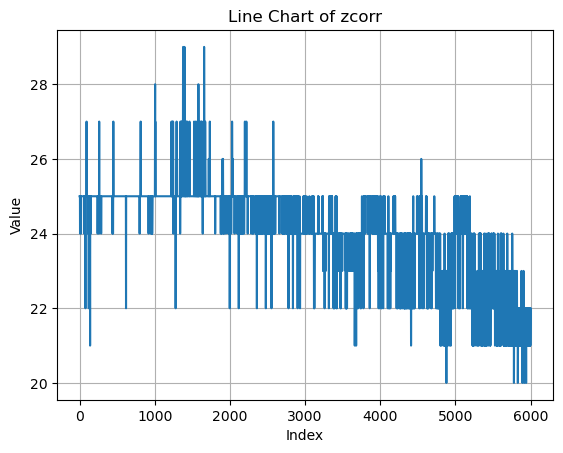

In [11]:
import matplotlib.pyplot as plt

def plot_zcorr(zcorr):
    plt.plot(zcorr)
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.title('Line Chart of zcorr')
    plt.grid(True)
    plt.show()

# Example usage
plot_zcorr(z_positions)

In [24]:
# compare suite2p data
import numpy as np
from scipy.io import loadmat

def load_mat_to_ndarray(file_path, variable_name):
    """
    Load a specified variable from a .mat file and convert it to a NumPy ndarray.
    
    Parameters:
    - file_path: str, the path to the .mat file.
    - variable_name: str, the name of the variable in the .mat file to convert to an ndarray.
    
    Returns:
    - ndarray: The specified variable as a NumPy ndarray.
    """
    # Load the .mat file
    data = loadmat(file_path)
    
    # Extract the specified variable
    if variable_name in data:
        ndarray = data[variable_name]
        # Check if the loaded data is structured or requires further processing
        if isinstance(ndarray, np.ndarray):
            return ndarray
        else:
            raise ValueError(f"{variable_name} is not stored as an ndarray.")
    else:
        raise KeyError(f"{variable_name} not found in the .mat file.")




In [25]:
# Usage example
file_path = "C:/Users/Kyle/Downloads/zcorr.mat"
ndarray = load_mat_to_ndarray(file_path,"zcorr")
print(ndarray)

[[0.00804396 0.00777526 0.00718485 ... 0.00939976 0.00964176 0.00979972]
 [0.00845242 0.00786621 0.00738527 ... 0.01005704 0.01053611 0.01045311]
 [0.00881689 0.00837163 0.00833795 ... 0.01083382 0.01114647 0.01111905]
 ...
 [0.02148525 0.02118526 0.0212484  ... 0.01739561 0.01689453 0.01651687]
 [0.01846333 0.01795833 0.01803731 ... 0.01472096 0.01440026 0.01395652]
 [0.01565396 0.01545509 0.01553833 ... 0.0125066  0.01249185 0.01189881]]


In [26]:
ndarray.shape

(41, 6000)

In [27]:
z_positions_suite2p = np.argmax(ndarray, axis=0)
print(z_positions_suite2p)

[25 25 25 ... 22 22 22]


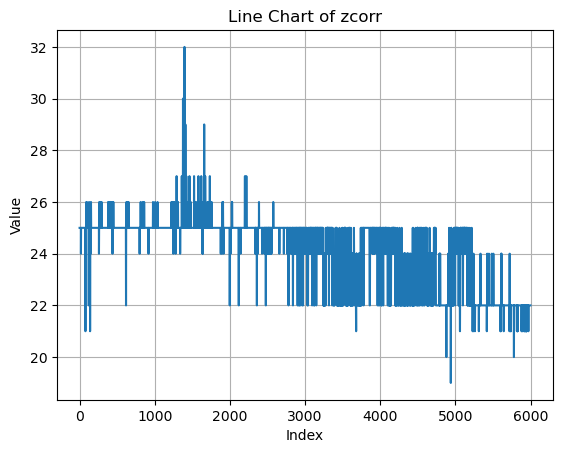

In [28]:
# Example usage
plot_zcorr(z_positions_suit2p)

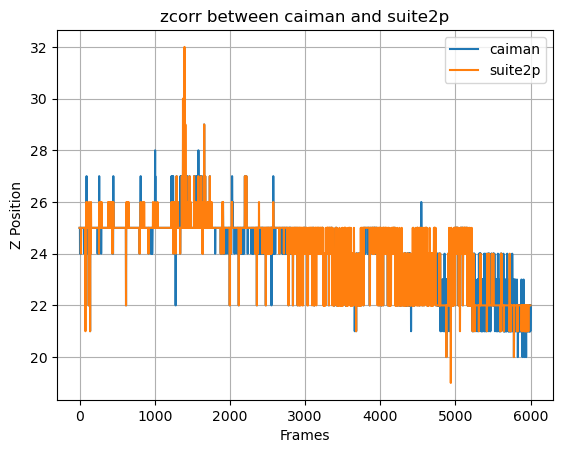

In [29]:
# plot two figures together
plt.plot(z_positions, label='caiman')
plt.plot(z_positions_suite2p, label='suite2p')
plt.xlabel('Frames') 
plt.ylabel('Z Position')
plt.title('zcorr between caiman and suite2p')
plt.legend()
plt.grid(True)
plt.show()


In [30]:
# compute the error rate between two z positions
error_rate = np.mean(z_positions != z_positions_suite2p)
error_rate

0.21666666666666667

In [37]:

# 找出不同值的索引
different_indices = [i for i, (a, b) in enumerate(zip(z_positions, z_positions_suite2p)) if a != b]
print("z_positions_caiman: ", z_positions)
print("z_positions_suite2p: ", z_positions_suite2p)
print("Index of difference frames: ", different_indices)
print(len(different_indices))

z_positions_caiman:  [25 25 25 ... 22 22 22]
z_positions_suite2p:  [25 25 25 ... 22 22 22]
Index of difference frames:  [6, 19, 61, 78, 79, 93, 94, 115, 126, 138, 141, 151, 152, 240, 261, 262, 274, 287, 293, 380, 389, 406, 407, 410, 416, 440, 441, 445, 449, 624, 639, 652, 811, 812, 813, 839, 859, 918, 945, 946, 947, 948, 949, 950, 961, 963, 966, 976, 977, 1003, 1004, 1005, 1007, 1037, 1223, 1226, 1228, 1229, 1230, 1236, 1244, 1252, 1259, 1278, 1296, 1300, 1309, 1342, 1348, 1353, 1354, 1361, 1366, 1372, 1376, 1393, 1395, 1396, 1404, 1408, 1419, 1432, 1463, 1468, 1479, 1531, 1532, 1543, 1546, 1555, 1564, 1569, 1580, 1581, 1582, 1583, 1585, 1590, 1594, 1615, 1638, 1641, 1642, 1643, 1651, 1656, 1658, 1659, 1661, 1667, 1669, 1672, 1702, 1717, 1720, 1722, 1726, 1729, 1730, 1732, 1738, 1744, 1757, 1804, 1887, 1901, 1902, 1920, 1921, 1922, 1947, 1980, 1981, 1983, 2009, 2017, 2026, 2029, 2030, 2038, 2062, 2101, 2102, 2104, 2119, 2130, 2131, 2141, 2143, 2144, 2146, 2152, 2153, 2154, 2155, 2156, 

In [38]:
import scipy.io

# Assuming z_positions and z_positions_suite2p are defined
different_indices = [i for i, (a, b) in enumerate(zip(z_positions, z_positions_suite2p)) if a != b]

# Create a dictionary to store the data
mat_data = {
    'z_positions_caiman': z_positions,
    'z_positions_suite2p': z_positions_suite2p,
    'index_of_difference_frames': different_indices
}

# Save the dictionary to a .mat file
scipy.io.savemat('difference_indices_01042024_1531_001.mat', mat_data)

print("Results have been saved to difference_indices.mat")


Results have been saved to difference_indices.mat
